# LAB12 — Hartëzimi i Fushës Magnetike
---
- ##### Tema: **Matja e B me magnetometrin e telefonit dhe ndërtimi i hartës 2D.**
- ##### Studenti: Florian loka
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 02.06.2026
---


## **Qëllimi (Purpose)**

Të matet fusha magnetike $\vec B$ në pika të ndryshme të hapësirës dhe të ndërtohet një
**hartë 2D** e intensitetit të saj. Përdorim magnetometrin e telefonit për të matur
komponentët $B_x,B_y,B_z$, llogarisim intensitetin total dhe vizualizojmë ndryshimin
hapësinor të fushës pranë një magneti, mbi sfondin e fushës së Tokës.


## **Hyrje Teorike (Theory)**

Fusha magnetike është madhësi **vektoriale**; në SI matet në tesla (T), por në smartphone
zakonisht në mikrotesla: $1\,\mu\text{T}=10^{-6}\,\text{T}$. Magnetometri raporton tre
komponentët $B_x,B_y,B_z$, dhe intensiteti total është:

$$ B = \sqrt{B_x^2 + B_y^2 + B_z^2} $$

Larg objekteve magnetike, sensori mat kryesisht **fushën e Tokës** (disa dhjetëra $\mu$T).
Për të izoluar ndikimin e magnetit zbresim sfondin:

$$ \Delta B = B - B_{\text{background}} $$

Afër një magneti të vogël, fusha sillet përafërsisht si **dipol**, duke rënë me largësinë:

$$ B \propto \frac{1}{r^3} $$


## **Aparatura dhe Pajisjet (Apparatus)**

- Smartphone me magnetometër; aplikacioni **phyphox** (*Magnetic field*).
- Një magnet i vogël permanent.
- Fletë me rrjetë (hap 2 cm), vizore, laptop me Python/Jupyter.

> **Shënim për të dhënat:** Skedarët në `data/` janë **reprezentativë** (të simuluar:
> sfond i tipit fushë Toke + perturbim dipoli) për të demonstruar analizën. Zëvendësoji me
> regjistrimet e tua nga phyphox; kontrollo emrat e kolonave dhe përshtati nëse duhet.
> Vlerat absolute të magnetometrit të telefonit nuk duhen besuar verbërisht (rikalibrim,
> magnetizim i brendshëm) — fokusi është te **ndryshimet relative** dhe harta.


## **Procedura (Procedure)**

1. **Sfondi (A):** telefoni mbi tavolinë, larg magneteve/metaleve; regjistro 30–60 s → `data/B_background.csv`.
2. **1D (B):** magnet në origjinë; mat $B_x,B_y,B_z$ në $x=2,4,\dots,16$ cm → `data/B_1D.csv`.
3. **2D (C):** rrjetë $9\times9$ (hap 2 cm), magnet në qendër; mat në çdo pikë → `data/B_map_2D.csv`.
4. Mbaj **të njëjtin orientim** të telefonit dhe të njëjtën pikë referimi gjatë gjithë matjeve.
5. Llogarit $B$, zbrit sfondin, vizualizo (scatter, heatmap, contour) dhe analizo rënien 1D.


## **Përpunimi Paraprak i të Dhënave (Preprocessing)**

Ngarkojmë tre skedarët, llogarisim intensitetin total \(B\) dhe vlerën e sfondit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)

def total_B(df):
    return np.sqrt(df["Bx_uT"]**2 + df["By_uT"]**2 + df["Bz_uT"]**2)

bg  = pd.read_csv("data/B_background.csv")
d1  = pd.read_csv("data/B_1D.csv")
mp  = pd.read_csv("data/B_map_2D.csv")

bg["B_uT"] = total_B(bg); d1["B_uT"] = total_B(d1); mp["B_uT"] = total_B(mp)
B_background = bg["B_uT"].mean()
d1["DeltaB_uT"] = d1["B_uT"] - B_background
mp["DeltaB_uT"] = mp["B_uT"] - B_background
print(f"Sfondi:  B_background = {B_background:.2f} µT  (σ = {bg['B_uT'].std(ddof=1):.2f} µT)")
print(f"Harta 2D: {len(mp)} pika,  B ∈ [{mp['B_uT'].min():.1f}, {mp['B_uT'].max():.1f}] µT")

Sfondi:  B_background = 47.78 µT  (σ = 0.40 µT)
Harta 2D: 81 pika,  B ∈ [48.1, 232.1] µT


## **Analiza e të Dhënave (Analysis)**

Stabiliteti i sfondit, harta 2D (heatmap + contour) dhe rënia 1D e fushës me largësinë.

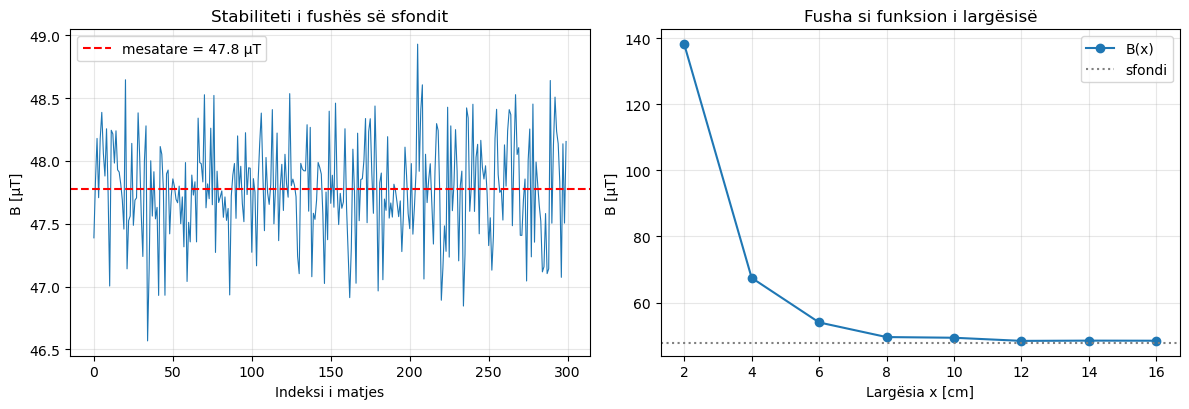

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
# Sfondi ne kohe
ax[0].plot(bg["time"], bg["B_uT"], lw=0.8)
ax[0].axhline(B_background, color="r", ls="--", label=f"mesatare = {B_background:.1f} µT")
ax[0].set_xlabel("Indeksi i matjes"); ax[0].set_ylabel("B [µT]")
ax[0].set_title("Stabiliteti i fushës së sfondit"); ax[0].legend(); ax[0].grid(alpha=0.3)
# 1D: B(x)
ax[1].plot(d1["x_cm"], d1["B_uT"], "o-", label="B(x)")
ax[1].axhline(B_background, color="gray", ls=":", label="sfondi")
ax[1].set_xlabel("Largësia x [cm]"); ax[1].set_ylabel("B [µT]")
ax[1].set_title("Fusha si funksion i largësisë"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIGS / "B_background_1D.png", dpi=150); plt.show()

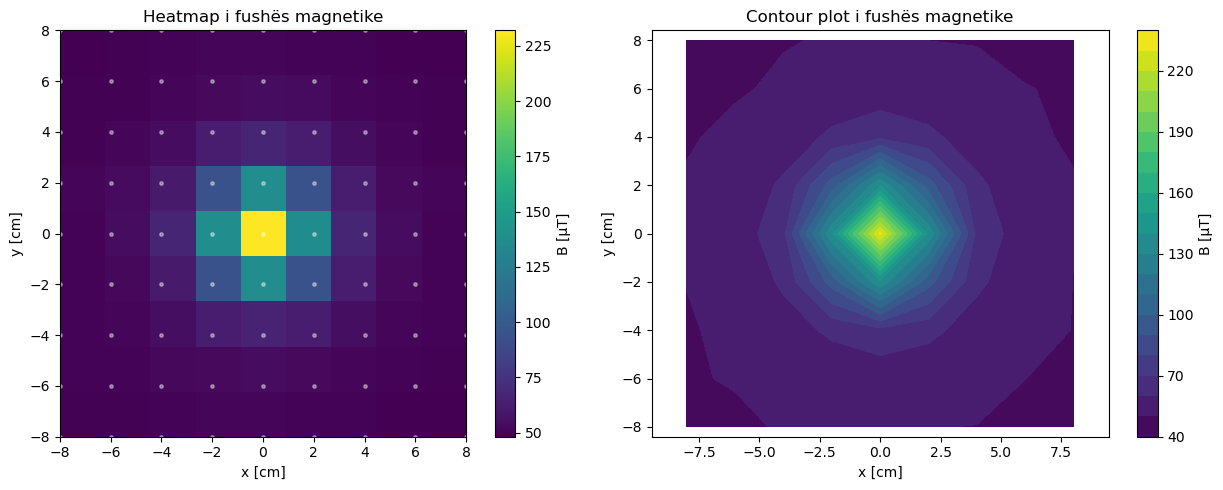

In [3]:
# Harta 2D: heatmap + contour
grid = mp.pivot(index="y_cm", columns="x_cm", values="B_uT")
X, Y, Z = grid.columns.to_numpy(), grid.index.to_numpy(), grid.values
ext = [X.min(), X.max(), Y.min(), Y.max()]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im = ax[0].imshow(Z, origin="lower", extent=ext, aspect="equal", cmap="viridis")
ax[0].scatter(mp["x_cm"], mp["y_cm"], c="white", s=6, alpha=0.4)
fig.colorbar(im, ax=ax[0], label="B [µT]")
ax[0].set_xlabel("x [cm]"); ax[0].set_ylabel("y [cm]"); ax[0].set_title("Heatmap i fushës magnetike")

cs = ax[1].contourf(X, Y, Z, levels=20, cmap="viridis")
fig.colorbar(cs, ax=ax[1], label="B [µT]")
ax[1].set_xlabel("x [cm]"); ax[1].set_ylabel("y [cm]")
ax[1].set_title("Contour plot i fushës magnetike"); ax[1].axis("equal")
fig.tight_layout(); fig.savefig(FIGS / "B_map_2D.png", dpi=150); plt.show()

## **Analiza e Pasigurisë (Uncertainty)**

Vlerësojmë eksponentin e rënies duke bërë fit log-log te $\Delta B$ kundrejt $r$:
$\Delta B \propto r^{-n}$. Për një dipol ideal pritet $n\approx 3$, por me smartphone
rezultati devijon (magneti s'është dipol ideal, pozicioni i sensorit i panjohur, sfond
jo-zero). Burimet kryesore të pasigurisë: orientimi i telefonit, rikalibrimi automatik,
objektet metalike pranë dhe lartësia e ndryshueshme e sensorit.

Eksponenti i përafërt i rënies:  n ≈ 2.55   (dipol ideal: 3)


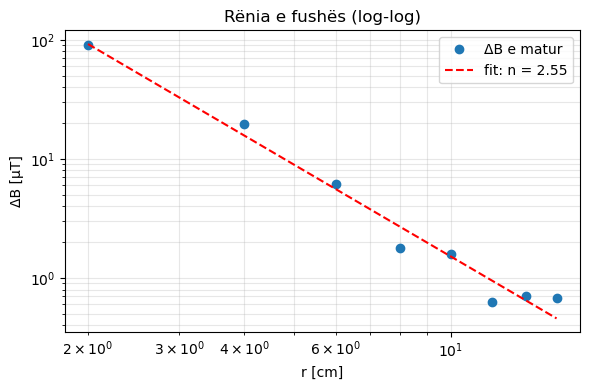

In [4]:
mask = d1["DeltaB_uT"] > 0
r = d1.loc[mask, "x_cm"].to_numpy(float)
dB = d1.loc[mask, "DeltaB_uT"].to_numpy(float)
slope, intercept = np.polyfit(np.log(r), np.log(dB), 1)
n_exp = -slope
print(f"Eksponenti i përafërt i rënies:  n ≈ {n_exp:.2f}   (dipol ideal: 3)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(r, dB, "o", label="ΔB e matur")
ax.loglog(r, np.exp(intercept)*r**slope, "r--", label=f"fit: n = {n_exp:.2f}")
ax.set_xlabel("r [cm]"); ax.set_ylabel("ΔB [µT]")
ax.set_title("Rënia e fushës (log-log)"); ax.legend(); ax.grid(True, which="both", alpha=0.3)
fig.tight_layout(); fig.savefig(FIGS / "B_loglog.png", dpi=150); plt.show()

## **Rezultatet (Results)**

| Eksperimenti | \(B_{min}\) | \(B_{max}\) | \(B_{mean}\) | \(\Delta B_{max}\) | (µT) |
|---|--:|--:|--:|--:|:--|

In [5]:
def row(name, B):
    return f"{name:<14}{B.min():>9.2f}{B.max():>9.2f}{B.mean():>9.2f}{(B.max()-B_background):>11.2f}"
print(f"{'Eksperimenti':<14}{'Bmin':>9}{'Bmax':>9}{'Bmean':>9}{'ΔBmax':>11}   (µT)")
print(row("Sfondi", bg["B_uT"]))
print(row("1D magnet", d1["B_uT"]))
print(row("Harta 2D", mp["B_uT"]))

Eksperimenti       Bmin     Bmax    Bmean      ΔBmax   (µT)
Sfondi            46.57    48.93    47.78       1.15
1D magnet         48.40   138.17    62.98      90.40
Harta 2D          48.14   232.05    61.54     184.28


## **Diskutimi (Discussion)**

- **Ku është fusha më e madhe?** Pranë magnetit (qendra e rrjetës), ku $\Delta B$ është maksimale.
- **A është harta simetrike?** Përafërsisht, por jo perfekt — magneti s'është dipol ideal
  dhe pozicioni i sensorit brenda telefonit është i panjohur.
- **A duket rënia $1/r^3$?** Eksponenti i matur është i rendit ~3 por devijon; afër magnetit
  fusha është komplekse, larg tij sfondi dominon.
- **Pse të zbresim sfondin?** Fusha e Tokës (~48 µT) maskon perturbimin e magnetit;
  $\Delta B$ e bën të dukshëm ndikimin lokal.
- **Pse mos t’i besojmë vlerës absolute?** Magnetometri i telefonit rikalibrohet
  automatikisht dhe ndikohet nga magnetizimi i brendshëm; është i mirë për ndryshime
  relative dhe harta, jo për matje absolute profesionale.


## **Përfundimi (Conclusion)**

Fusha magnetike mund të trajtohet si një **madhësi fizike e matshme në hapësirë**. Me një
sensor të thjeshtë (magnetometri i telefonit) ndërtuam një hartë 2D të intensitetit,
izoluam perturbimin e magnetit nga sfondi i Tokës (\(\Delta B\)) dhe vlerësuam rënien e
fushës me largësinë. Mesazhi kryesor: **një sensor i thjeshtë jep të dhëna interesante, por
interpretimi fizik kërkon kontroll të kushteve dhe analizë kritike të kufizimeve të
instrumentit.** *(Zëvendëso të dhënat reprezentative me matjet e tua reale.)*
